## Step01

In [8]:
import pandas as pd
import numpy as np

from pathlib import Path

DATA_PATH = Path("data/project_dataset.csv")
project_dataset = pd.read_csv(DATA_PATH, sep=';')

print("csv file is loaded successfully")
project_dataset.head()
## data inspection checking for missing data
project_dataset.info()
project_dataset.isnull().sum()
## removing duplicates 

project_dataset.duplicated().sum()
project_dataset= project_dataset.drop_duplicates()
## converting data to their appropriate types

project_dataset.dtypes
# --- DATE ---
project_dataset["Date"] = pd.to_datetime(project_dataset["Date"], errors="coerce")


# --- CATEGORICAL TEXT ---
categorical_cols = [
    "Service",
    "Gare de départ",
    "Gare d'arrivée",
    "Commentaire annulations",
    "Commentaire retards au départ",
    "Commentaire retards à l'arrivée"
]

for col in categorical_cols:
    project_dataset[col] = project_dataset[col].astype("category")


# --- INTEGER COUNTS ---
int_cols = [
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Nombre de trains en retard au départ",
    "Nombre de trains en retard à l'arrivée",
    "Nombre trains en retard > 15min",
    "Nombre trains en retard > 30min",
    "Nombre trains en retard > 60min"
]

for col in int_cols:
    project_dataset[col] = pd.to_numeric(project_dataset[col], errors="coerce").astype("Int64")


# --- FLOAT / CONTINUOUS VALUES ---
float_cols = [
    "Durée moyenne du trajet",
    "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ",
    "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
    "Prct retard pour causes externes",
    "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic",
    "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
]

for col in float_cols:
    project_dataset[col] = pd.to_numeric(project_dataset[col], errors="coerce")

## extract features as from the task (year and month)

project_dataset["Year"]= project_dataset["Date"].dt.year
project_dataset["Month"]=project_dataset["Date"].dt.month


## the output ("cleaned_dataset")
CLEAN_PATH = Path("cleaned_dataset.csv")
project_dataset.to_csv(CLEAN_PATH, index=False)

print("cleaned dataset saved to:", CLEAN_PATH)

csv file is loaded successfully
<class 'pandas.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 26 columns):
 #   Column                                                                                       Non-Null Count  Dtype
---  ------                                                                                       --------------  -----
 0   Date                                                                                         12010 non-null  str  
 1   Service                                                                                      11830 non-null  str  
 2   Gare de départ                                                                               12011 non-null  str  
 3   Gare d'arrivée                                                                               12011 non-null  str  
 4   Durée moyenne du trajet                                                                      11830 non-null  str  
 5   Nombre de circulations pr

# Exploratory Data Analysis (EDA)

In [9]:
from pathlib import Path
import pandas as pd

CLEAN_PATH = Path("cleaned_dataset.csv")
df = pd.read_csv(CLEAN_PATH)

df.head()

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",Year,Month
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,NaN,289.0,11.247809,...,44.0,8.0,36.134454,31.092437,10.924370,15.966387,NaN,0.840336,2018.0,1.0
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,NaN,213.0,8.479969,...,9.0,4.0,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018.0,1.0
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,NaN,21.0,6.239683,...,6.0,1.0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018.0,1.0
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211,...,18.0,NaN,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018.0,1.0
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,NaN,224.0,6.784673,...,10.0,0.0,15.789474,45.614035,NaN,15.789474,1.754386,1.754386,2018.0,1.0


In [10]:
round(df["Retard moyen des trains en retard au départ"].mean(), 2)

np.float64(12.31)

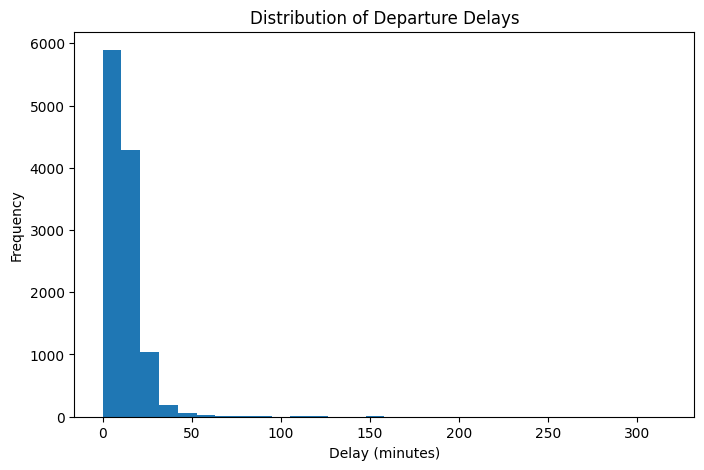

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["Retard moyen des trains en retard au départ"], bins=30)
plt.title("Distribution of Departure Delays")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.show()

In [12]:
avg_delay_by_year = df.groupby("Year")["Retard moyen des trains en retard au départ"].mean().sort_index()
avg_delay_by_year

Year
2018.0    12.228328
2019.0    12.632315
2020.0     4.592908
2021.0    11.792066
2022.0    13.207354
2023.0    14.568177
2024.0    14.032543
2025.0    15.393445
Name: Retard moyen des trains en retard au départ, dtype: float64

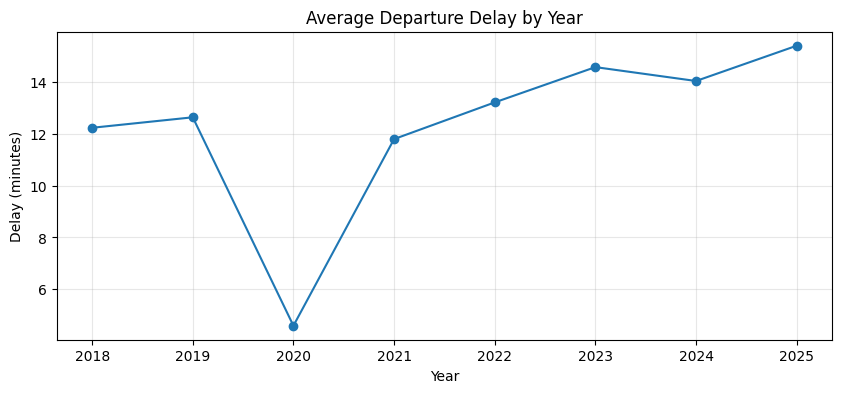

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(avg_delay_by_year.index, avg_delay_by_year.values, marker="o")
plt.title("Average Departure Delay by Year")
plt.xlabel("Year")
plt.ylabel("Delay (minutes)")
plt.grid(True, alpha=0.3)
plt.show()

### Insight: Evolution of Departure Delays Over Time

The average departure delay significantly dropped in 2020 (4.59 minutes), likely due to reduced train traffic during the COVID-19 period
However, from 2021 onwards, delays increased steadily, reaching more than 15 minutes in 2025.This suggests a worsening delay trend in recent years